# HAH913E Physical Activity Assignment

## GitHub Repository
https://github.com/your-team-name/your-repository

## Team Members
- Student 1
- Student 2

## Objective

The goal is to compute ENMO (Euclidean Norm Minus One) from raw wrist accelerometer data and aggregate it using different epoch lengths (10 s, 30 s and 60 s).

Epoch aggregation reduces the data volume and allows comparison of physical activity intensity over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

The file contains:

- t: time in seconds
- x: acceleration along x-axis (g)
- y: acceleration along y-axis (g)
- z: acceleration along z-axis (g)

The data comes from a wrist-worn Axivity AX3 accelerometer.

In [13]:
df = pd.read_csv("C:\\Users\\Said Rodriguez\\Desktop\\M2\\Santé Physique\\0_z.csv")

df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Computing ENMO

First we calculate the Euclidean norm of the three acceleration components.

Then we subtract 1 g (Earth's gravity) and truncate negative values to zero.

In [14]:
def compute_enmo(df):
    norm = np.sqrt(df["x"]**2 +
                   df["y"]**2 +
                   df["z"]**2)

    enmo = np.maximum(norm - 1, 0)

    return enmo

df["ENMO"] = compute_enmo(df)

## Aggregating ENMO by Epoch

An epoch is a fixed time window.

We calculate the mean ENMO value for epochs of:
- 10 seconds
- 30 seconds
- 60 seconds

In [19]:
def integrate_enmo(df, epoch_length):

    temp = df.copy()

    temp["epoch"] = (temp["t"] // epoch_length).astype(int)

    integrated = (
        temp.groupby("epoch")["ENMO"]
        .sum()
        .reset_index()
    )

    integrated["time"] = integrated["epoch"] * epoch_length

    return integrated

In [20]:
enmo_10 = integrate_enmo(df, 10)
enmo_30 = integrate_enmo(df, 30)
enmo_60 = integrate_enmo(df, 60)

In [21]:
dt = np.mean(np.diff(df["t"]))

## Plotting Results

We compare ENMO aggregated over three different epoch lengths.

Short epochs preserve more detail while longer epochs smooth fluctuations.

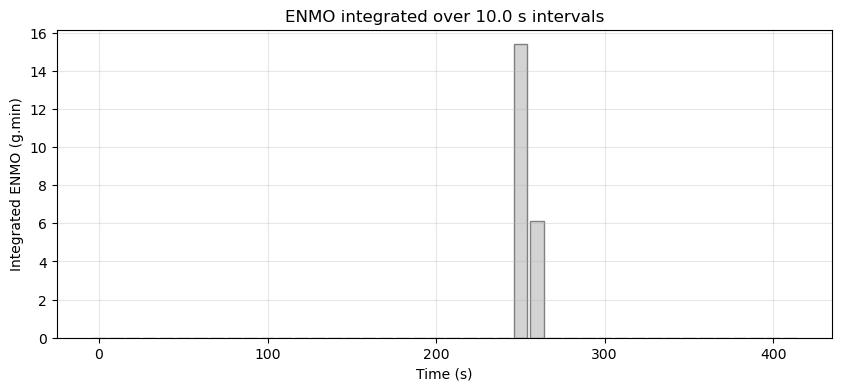

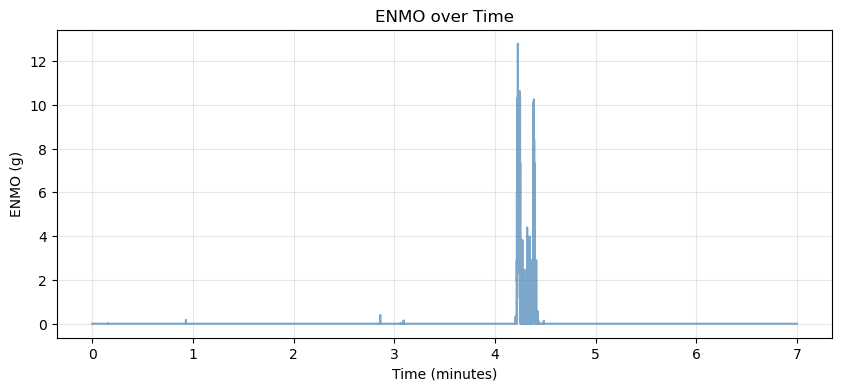

In [31]:
# 10 s epochs
enmo10 = integrate_enmo(df, 10)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo10["time"],
    enmo10["Integrated_ENMO"],
    width=8,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 10.0 s intervals")
plt.xlabel("Time (s)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()



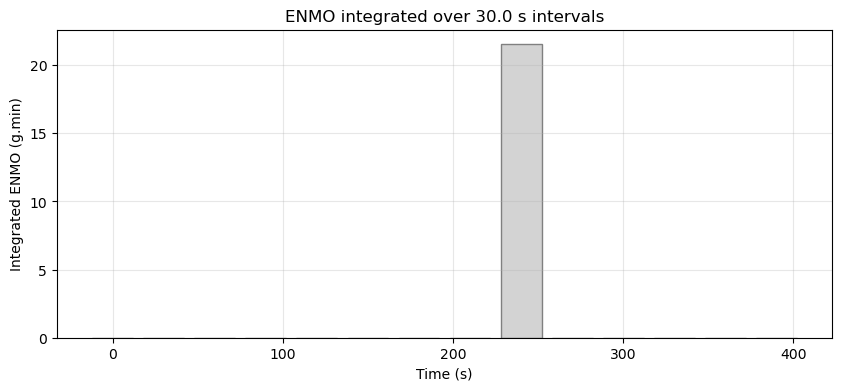

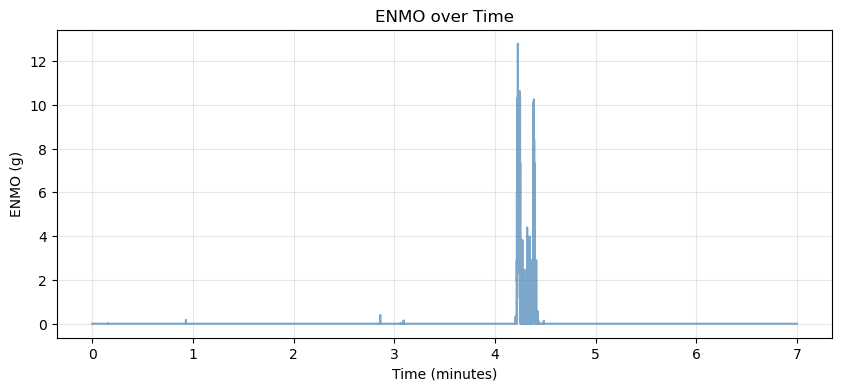

In [29]:
# 30 s epochs
enmo30 = integrate_enmo(df, 30)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo30["time"],
    enmo30["Integrated_ENMO"],
    width=24,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 30.0 s intervals")
plt.xlabel("Time (s)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()

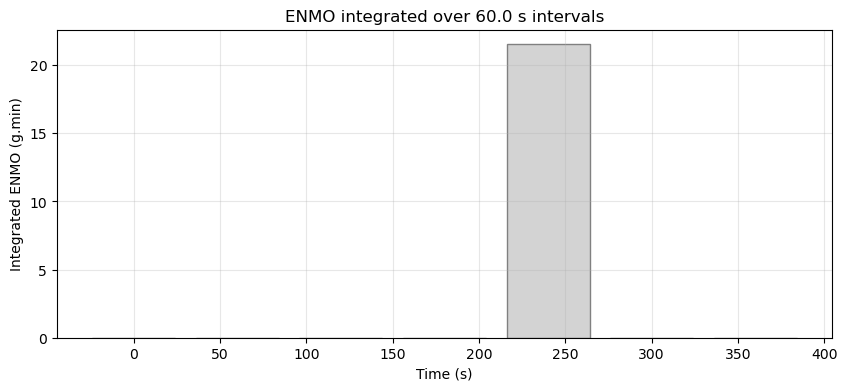

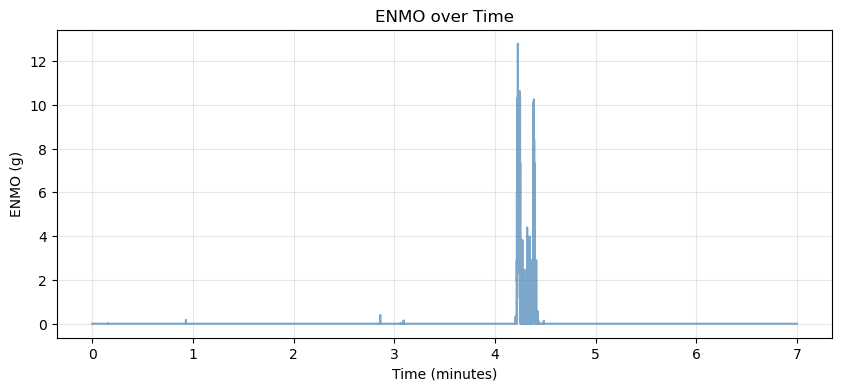

In [30]:
# 60 s epochs
enmo60 = integrate_enmo(df, 60)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo60["time"],
    enmo60["Integrated_ENMO"],
    width=48,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 60.0 s intervals")
plt.xlabel("Time (s)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()

## Discussion

The 10-second epoch provides the highest temporal resolution and captures rapid changes in activity.

The 30-second epoch smooths short-term fluctuations while preserving overall activity patterns.

The 60-second epoch produces the smoothest curve and is useful for studying long-term trends.

Increasing epoch length reduces noise but also reduces temporal detail.